# 05: Explainability
**Goal:** Apply SHAP to the trained LSTM risk model from Notebook 02, and explain a
small number of specific high-risk forecasts rather than every prediction in the test
set.
$$ \phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!\,(|N|-|S|-1)!}{|N|!} \Big[ f(S \cup \{i\}) - f(S) \Big] $$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import shap
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
HORIZON, LOOKBACK = 5, 20

returns = pd.read_csv(PROCESSED / "log_returns.csv", index_col=0, parse_dates=True)
tickers = returns.columns.tolist()
target = returns.rolling(HORIZON).std().shift(-HORIZON) * np.sqrt(252)

n = len(returns)
train_end = returns.index[int(n * 0.70)]
val_end = returns.index[int(n * 0.85)]
train_mask = returns.index <= train_end
test_mask = returns.index > val_end

In [2]:
class VolLSTM(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden, num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        return self.head(h[-1])

model = VolLSTM()
model.load_state_dict(torch.load(PROCESSED / "lstm_vol_model.pt"))
model.eval()
print("model loaded")

model loaded


In [3]:
def build_sequences(returns_df, target_df, mask, lookback=LOOKBACK):
    roll5_df = returns_df.rolling(5).std() * np.sqrt(252)
    X, y, idx_ticker, idx_date = [], [], [], []
    for tkr in returns_df.columns:
        r = returns_df[tkr].values
        v = roll5_df[tkr].values
        t = target_df[tkr].values
        dates = returns_df.index
        for pos in np.where(mask)[0]:
            if pos - lookback < 0 or np.isnan(t[pos]):
                continue
            r_window, v_window = r[pos - lookback:pos], v[pos - lookback:pos]
            if np.isnan(r_window).any() or np.isnan(v_window).any():
                continue
            X.append(np.stack([r_window, v_window], axis=-1))
            y.append(t[pos])
            idx_ticker.append(tkr)
            idx_date.append(dates[pos])
    X = np.array(X, dtype=np.float32).reshape(-1, lookback, 2)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    return X, y, idx_ticker, idx_date

X_train, y_train, _, _ = build_sequences(returns, target, train_mask)
X_test, y_test, test_tickers, test_dates = build_sequences(returns, target, test_mask)
X_train.shape, X_test.shape

((20230, 20, 2), (4330, 20, 2))

## Picking case studies: the highest predicted-risk days

In [4]:
with torch.no_grad():
    test_preds = model(torch.tensor(X_test)).numpy().flatten()

top5_idx = np.argsort(test_preds)[-5:][::-1]
case_studies = pd.DataFrame({
    "ticker": [test_tickers[i] for i in top5_idx],
    "date": [test_dates[i].date() for i in top5_idx],
    "predicted_vol": [test_preds[i] for i in top5_idx],
})
case_studies

,ticker,date,predicted_vol
0,GLD,2026-02-06,5.283985
1,GLD,2026-02-05,5.161627
2,GLD,2026-02-04,4.739769
3,GLD,2026-02-09,4.289521
4,GLD,2026-02-03,3.659889


## Running SHAP

`shap.DeepExplainer` was tried first, since it is the standard choice for PyTorch
models, but failed its own internal consistency check on this LSTM (a known
compatibility gap between DeepExplainer and recurrent layers, not specific to this
model). `shap.GradientExplainer` is used instead, it supports the same class of
gradient-based attribution and works cleanly here.

In [5]:
rng = np.random.default_rng(42)
bg_idx = rng.choice(len(X_train), size=100, replace=False)
background = torch.tensor(X_train[bg_idx])
explain_samples = torch.tensor(X_test[top5_idx])

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(explain_samples)
shap_values = np.array(shap_values).squeeze(-1)  # (5, lookback, 2)
shap_values.shape

(5, 20, 2)

## Case study: the single highest-predicted-risk day

Explaining: GLD on 2026-02-06 (predicted vol = 5.284)


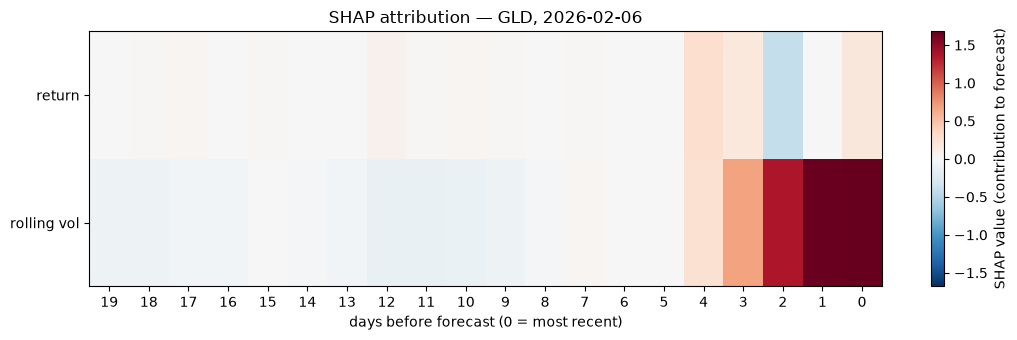

In [6]:
top_case = case_studies.iloc[0]
print(f"Explaining: {top_case['ticker']} on {top_case['date']} (predicted vol = {top_case['predicted_vol']:.3f})")

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(shap_values[0].T, aspect="auto", cmap="RdBu_r",
               vmin=-np.abs(shap_values[0]).max(), vmax=np.abs(shap_values[0]).max())
ax.set_yticks([0, 1])
ax.set_yticklabels(["return", "rolling vol"])
ax.set_xlabel("days before forecast (0 = most recent)")
ax.set_xticks(range(LOOKBACK))
ax.set_xticklabels(range(LOOKBACK - 1, -1, -1))
ax.set_title(f"SHAP attribution — {top_case['ticker']}, {top_case['date']}")
plt.colorbar(im, ax=ax, label="SHAP value (contribution to forecast)")
plt.tight_layout()
plt.show()

## Aggregate feature importance across all five case studies

In [7]:
mean_abs_by_feature = np.abs(shap_values).mean(axis=1)  # (5 cases, 2 features)
importance_df = pd.DataFrame(mean_abs_by_feature, columns=["return", "rolling_vol"])
importance_df.index = [f"{r.ticker} {r.date}" for r in case_studies.itertuples()]
importance_df["ratio"] = importance_df["rolling_vol"] / importance_df["return"]
importance_df.round(4)

,return,rolling_vol,ratio
GLD 2026-02-06,0.0669,0.3238,4.8374
GLD 2026-02-05,0.0714,0.2943,4.1222
GLD 2026-02-04,0.0775,0.2484,3.2035
GLD 2026-02-09,0.0752,0.3441,4.5784
GLD 2026-02-03,0.0558,0.1498,2.6825


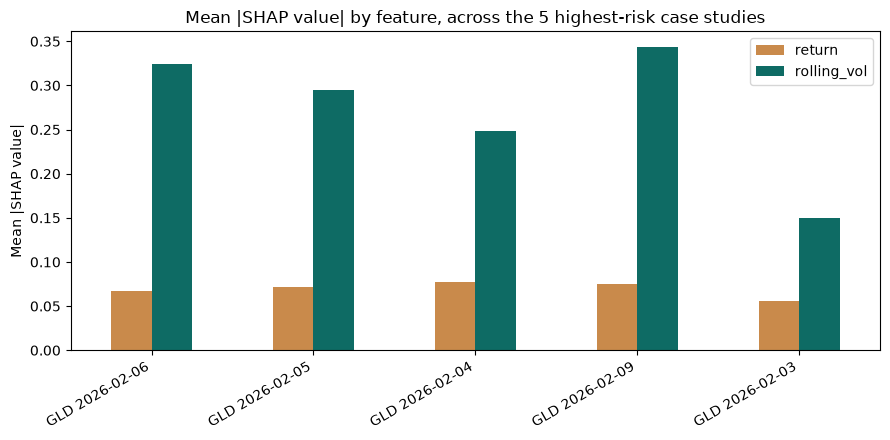

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
importance_df[["return", "rolling_vol"]].plot(kind="bar", ax=ax, color=["#c98a4b", "#0e6b64"])
ax.set_title("Mean |SHAP value| by feature, across the 5 highest-risk case studies")
ax.set_ylabel("Mean |SHAP value|")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Save outputs

In [9]:
np.save(PROCESSED / "shap_values_case_studies.npy", shap_values)
case_studies.to_csv(PROCESSED / "shap_case_studies.csv", index=False)
importance_df.to_csv(PROCESSED / "shap_feature_importance.csv")
print("Saved: shap_values_case_studies.npy, shap_case_studies.csv, shap_feature_importance.csv")

Saved: shap_values_case_studies.npy, shap_case_studies.csv, shap_feature_importance.csv
